In [42]:
import json
import sys
from pathlib import Path

import pandas as pd
from sklearn.inspection import permutation_importance

from ml_enhance import custom_train_test_split, load_hpc_result

def filter_X(X: pd.DataFrame) -> pd.DataFrame:
    drop_qm_features = [
        "radius_of_gyration",
        "molecular_volume",
        "sterimol_L",
        "sterimol_Bmin",
        "sterimol_Bmax",
        "molecular_sasa",
        "solvation_energy_thf",
        "solvation_energy_cyclohexane",
        "solvation_energy_dmso",
        "avg_percentage_buried_volume",
        "min_percentage_buried_volume",
        "max_percentage_buried_volume",
        "std_percentage_buried_volume",
        "avg_atomic_sasa",
        "min_atomic_sasa",
        "max_atomic_sasa",
        "std_atomic_sasa",
        "min_partial_charge_thf",
        "max_partial_charge_thf",
        "std_partial_charge_thf",
        "min_partial_charge_cyclohexane",
        "max_partial_charge_cyclohexane",
        "std_partial_charge_cyclohexane",
        "min_partial_charge_dmso",
        "max_partial_charge_dmso",
        "std_partial_charge_dmso",
        "avg_bond_length",
        "min_bond_length",
        "max_bond_length",
        "std_bond_length",
        "avg_bond_stiffness",
        "min_bond_stiffness",
        "max_bond_stiffness",
        "std_bond_stiffness",
        "avg_effective_coordination_number",
        "min_effective_coordination_number",
        "max_effective_coordination_number",
        "std_effective_coordination_number",
    ]

    drop_topo_features = [
        "MaxPartialCharge",
        "MinPartialCharge",
        "MaxAbsPartialCharge",
        "MinAbsPartialCharge",
    ]

    return X.drop(
        [
            "avg_atomic_quadrupole_principal_invariant_3",  # quadrupole principal invariant 3 features correlate highly with the invariant 2 features, so can drop them
            "max_atomic_quadrupole_principal_invariant_3",
            "molecular_quadrupole_principal_invariant_3",
            "avg_atomic_dipole_dipole_interaction",  # the dipole dipole interaction between atoms would physically not be that influential on the solubility, can drop it
        ]
        + drop_qm_features
        + drop_topo_features,
        axis=1,
    )



file_path = Path("data/RF_results/RF_combo_filtered_results.pkl")
fold_id = 0

splits_file = Path("hpc_splits.pkl")
rdkit_file = Path("data/rdkit_feature_names.json")

df = pd.read_csv("data/processed_dataset_wo_metals_w_even_more_qm2.csv")
X = df.drop(["solubility", "smiles", "canon_smiles", "id"], axis=1)
X_filtered = filter_X(X)
y = df["solubility"]

model_df: pd.DataFrame = load_hpc_result(file_path, file_path.stem)
model = model_df["estimator"][fold_id]

_, X_test, _, y_test = custom_train_test_split(splits_file, fold_id, X_filtered, y)

scoring = {"r2": "r2", "MSE": "neg_mean_squared_error"}

PFI = permutation_importance(model, X_test, y_test, scoring=scoring, n_repeats=20, random_state=9, n_jobs=4)

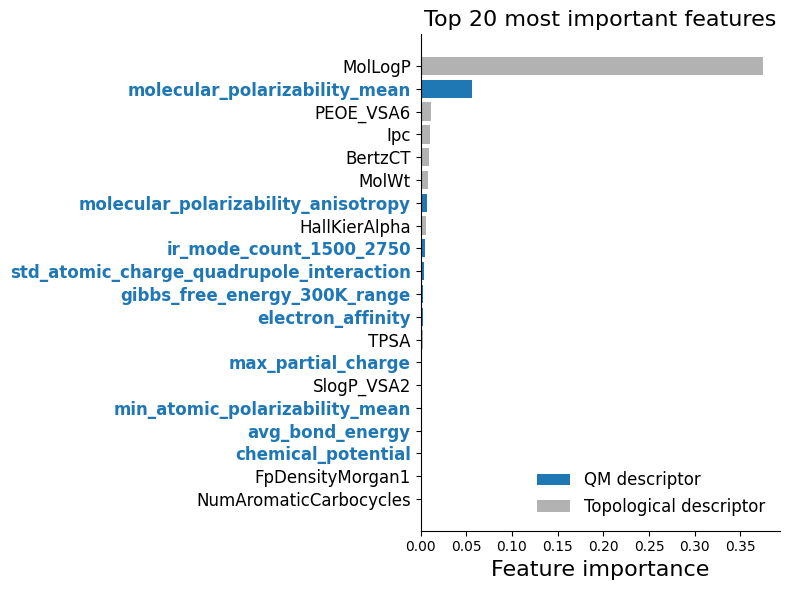

In [43]:
from ml_enhance import plot_FI


df = pd.concat(
    {
        metric: pd.DataFrame({
            "mean": r.importances_mean,
            "std": r.importances_std
        })
        for metric, r in PFI.items()
    },
    axis=1
)
df.index = X_test.columns
df.columns = [f"{metric}_{stat}" for metric, stat in df.columns]
plot_FI(df['r2_mean'], 20)